# Análisis exploratorio de datos (EDA): CESNET-TLS-Year22

**Proyecto:** Análisis comparativo de modelos de aprendizaje automático y arquitecturas Transformer para la clasificación de tráfico de red cifrado sobre el dataset CESNET-TLS-Year22
**Autor:** Jairo Jhayya Perlaza · Proyecto Integrador en IA (MIAR0545), semana 2

El análisis tiene dos fuentes:

1. **Las estadísticas diarias del dataset** (`stats-*.json`): cuentan los flujos por servicio de los 365 días de 2022. Sirven para ver la distribución de clases y la deriva de todo el año sin leer los flujos.
2. **Una muestra aleatoria del 2 % de septiembre a diciembre de 2022**, generada con `scripts/01_extraer_muestra.py`. Es la misma proporción de la submuestra XS de DataZoo y cubre los meses del diseño experimental: septiembre para entrenar, octubre para probar, noviembre y diciembre para medir la deriva.

Todas las cifras que aparecen en este notebook se calculan a partir de los datos; ninguna está escrita a mano.

In [1]:
import os, json, re, shutil, zipfile, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from scipy.stats import ks_2samp
from sklearn.metrics import normalized_mutual_info_score

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path(os.environ.get("PI_ROOT", Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
ZIP = Path(os.environ.get("PI_ZIP", ROOT / "datasets" / "CESNET-TLS-Year22.zip"))
SERVICEMAP = Path(os.environ.get("PI_SERVICEMAP", ROOT / "datasets" / "servicemap.csv"))
SAMPLE = Path(os.environ.get("PI_SAMPLE", ROOT / "data" / "processed" / "muestra_2pct"))
OUT = Path(os.environ.get("PI_OUT", ROOT / "results" / "eda"))
FIG = OUT / "figuras"
FIG.mkdir(parents=True, exist_ok=True)

TRAIN, TEST, DRIFT = "2022-09", "2022-10", ["2022-11", "2022-12"]
SEED = 42
SEQ = 30
GRIS = "#4a4a4a"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.titleweight": "bold"})
SUMMARY = {}

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIG / f"{nombre}.png", bbox_inches="tight")
    plt.show()

for p in [ZIP, SERVICEMAP, SAMPLE]:
    print(("OK   " if p.exists() else "FALTA"), p)

OK    /home/ransomware/proyecto_integrador/jairojhayya/datasets/CESNET-TLS-Year22.zip
OK    /home/ransomware/proyecto_integrador/jairojhayya/datasets/servicemap.csv
OK    /home/ransomware/proyecto_integrador/jairojhayya/data/processed/muestra_2pct


## 1. Panorama del año completo (estadísticas diarias)

Se leen los 365 archivos `stats-*.json` directamente del zip y se asigna a cada servicio su categoría con el mapa oficial `servicemap.csv`.

In [2]:
rows, totals = [], []
with zipfile.ZipFile(ZIP) as z:
    for name in z.namelist():
        m = re.search(r"stats-(\d{8})\.json$", name)
        if not m:
            continue
        s = json.loads(z.read(name))
        day = m.group(1)
        totals.append((day, s.get("global", {}).get("total-saved", np.nan)))
        rows += [(day, app, c) for app, c in s.get("apps", {}).items()]

stats = pd.DataFrame(rows, columns=["day", "APP", "flows"])
stats["DATE"] = pd.to_datetime(stats["day"], format="%Y%m%d")
stats["MONTH"] = stats["DATE"].dt.strftime("%Y-%m")
sm = pd.read_csv(SERVICEMAP)
tag2cat = dict(zip(sm["Tag"], sm["Service Category"]))
stats["CATEGORY"] = stats["APP"].map(tag2cat)
day_tot = pd.DataFrame(totals, columns=["day", "total_saved"]).sort_values("day")
day_tot["DATE"] = pd.to_datetime(day_tot["day"], format="%Y%m%d")

sin_cat = sorted(stats.loc[stats["CATEGORY"].isna(), "APP"].unique())
SUMMARY["anio"] = {
    "dias": int(stats["day"].nunique()),
    "flujos_totales": int(day_tot["total_saved"].sum()),
    "servicios": int(stats["APP"].nunique()),
    "servicios_en_servicemap": int(sm["Tag"].nunique()),
    "categorias": int(sm["Service Category"].nunique()),
    "servicios_sin_categoria": sin_cat,
    "flujos_diarios_media": float(day_tot["total_saved"].mean()),
    "flujos_diarios_min": int(day_tot["total_saved"].min()),
    "flujos_diarios_max": int(day_tot["total_saved"].max()),
}
print(json.dumps(SUMMARY["anio"], indent=1, ensure_ascii=False))

{
 "dias": 357,
 "flujos_totales": 507739073,
 "servicios": 180,
 "servicios_en_servicemap": 180,
 "categorias": 23,
 "servicios_sin_categoria": [],
 "flujos_diarios_media": 1391065.9534246575,
 "flujos_diarios_min": 0,
 "flujos_diarios_max": 2770538
}


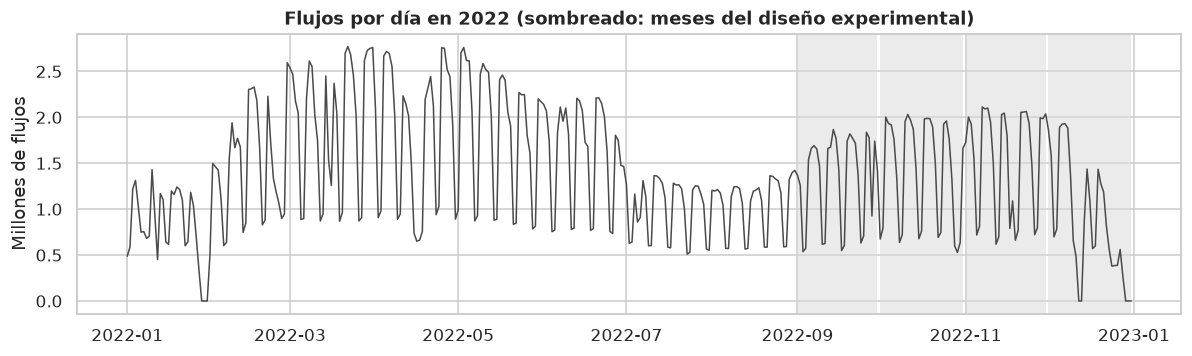

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(day_tot["DATE"], day_tot["total_saved"] / 1e6, color=GRIS, lw=1)
for mes in [TRAIN, TEST] + DRIFT:
    ax.axvspan(pd.Timestamp(mes + "-01"), pd.Timestamp(mes + "-01") + pd.offsets.MonthEnd(0), color="#d9d9d9", alpha=0.5, lw=0)
ax.set_title("Flujos por día en 2022 (sombreado: meses del diseño experimental)")
ax.set_ylabel("Millones de flujos")
guardar("01_flujos_por_dia")

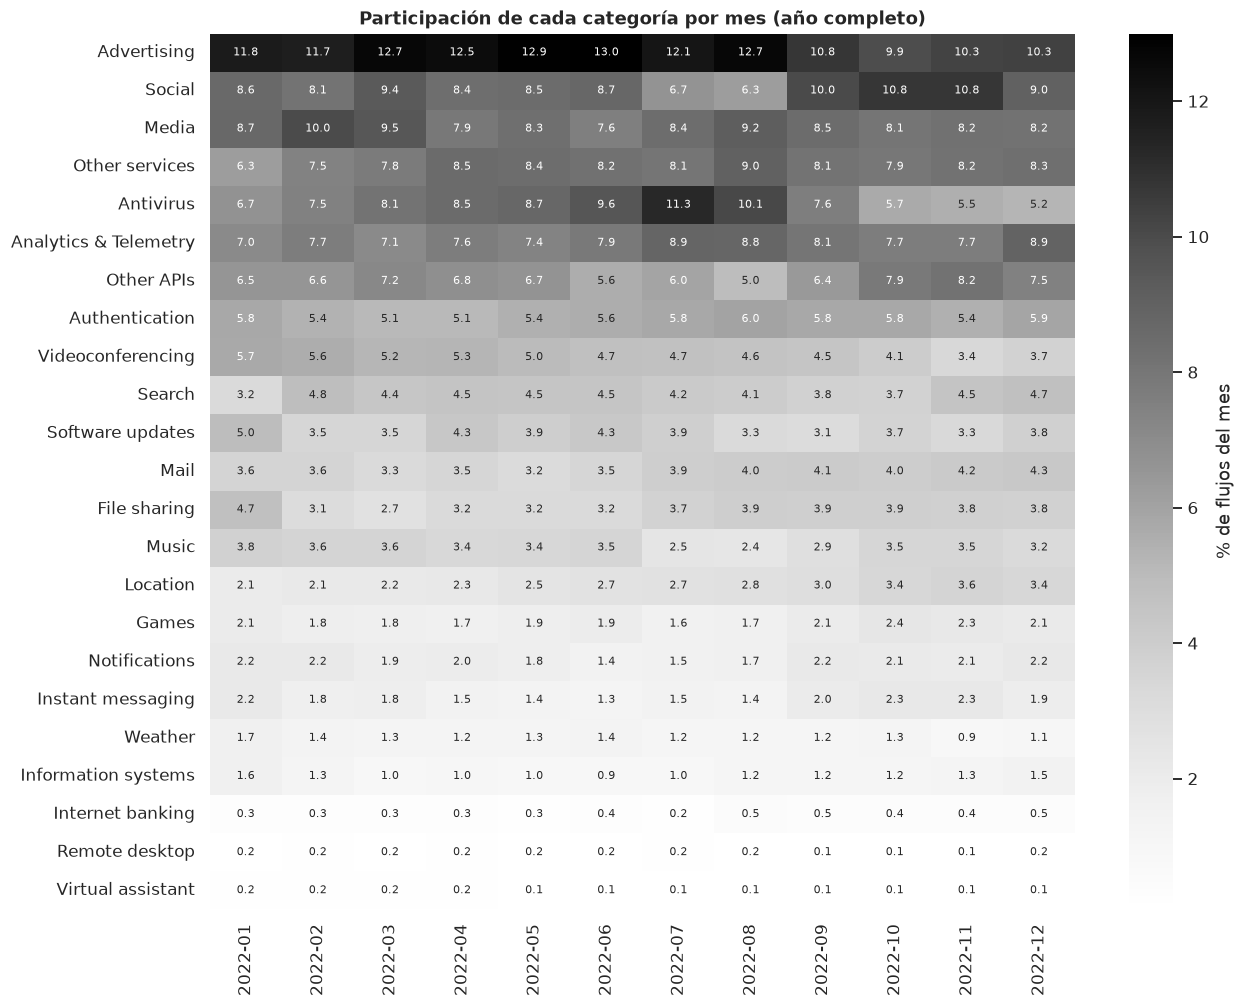

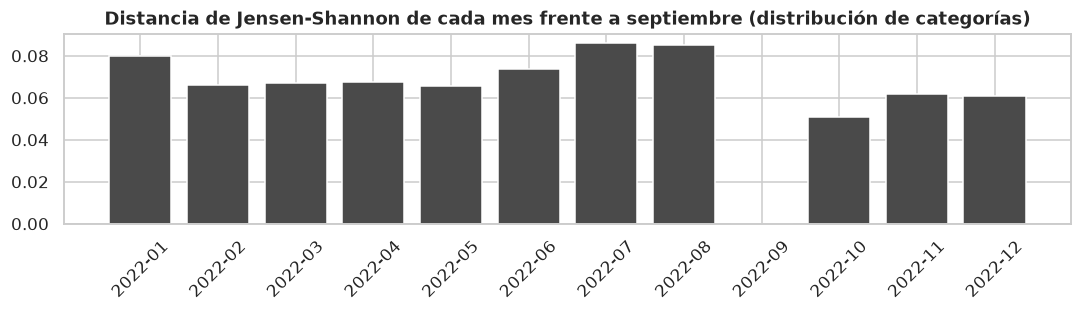

In [4]:
cat_mes = stats.dropna(subset=["CATEGORY"]).pivot_table(index="CATEGORY", columns="MONTH", values="flows", aggfunc="sum", fill_value=0)
cat_mes_pct = cat_mes / cat_mes.sum(axis=0)
orden = cat_mes.sum(axis=1).sort_values(ascending=False).index
cat_mes_pct = cat_mes_pct.loc[orden]
cat_mes_pct.to_csv(OUT / "categorias_por_mes_anio.csv")

fig, ax = plt.subplots(figsize=(12, 0.34 * len(orden) + 1.5))
sns.heatmap(cat_mes_pct * 100, cmap="Greys", annot=True, fmt=".1f", cbar_kws={"label": "% de flujos del mes"}, ax=ax, annot_kws={"size": 7})
ax.set_title("Participación de cada categoría por mes (año completo)")
ax.set_xlabel(""); ax.set_ylabel("")
guardar("02_categorias_por_mes_anio")

ref = cat_mes_pct[TRAIN] if TRAIN in cat_mes_pct else cat_mes_pct.iloc[:, 0]
js = {m: float(jensenshannon(ref, cat_mes_pct[m], base=2)) for m in cat_mes_pct.columns}
js_df = pd.Series(js, name="JS_vs_sep").to_frame()
js_df.to_csv(OUT / "deriva_js_anio.csv")
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(js_df.index, js_df["JS_vs_sep"], color=GRIS)
ax.set_title("Distancia de Jensen-Shannon de cada mes frente a septiembre (distribución de categorías)")
ax.tick_params(axis="x", rotation=45)
guardar("03_deriva_js_anio")
SUMMARY["deriva_anio_js_vs_septiembre"] = {k: round(v, 4) for k, v in js.items()}

## 2. Carga de la muestra de septiembre a diciembre

La muestra se generó con una semilla fija (42), así que es reproducible. Aquí se comprueba que la fracción real coincide con la configurada.

In [5]:
files = sorted(SAMPLE.glob("*.parquet"))
df = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)
for c in ["APP", "CATEGORY"]:
    df[c] = df[c].astype("category")
df["MONTH"] = df["DATE"].dt.strftime("%Y-%m")
df["SPLIT"] = np.select([df["MONTH"] == TRAIN, df["MONTH"] == TEST], ["entrenamiento", "prueba"], "deriva")
manifest = pd.DataFrame(json.loads((SAMPLE / "manifest.json").read_text())).T
manifest["MONTH"] = pd.to_datetime(manifest["day"], format="%Y%m%d").dt.strftime("%Y-%m")
manifest[["total_flows", "sampled"]] = manifest[["total_flows", "sampled"]].astype(int)
por_mes = manifest.groupby("MONTH")[["total_flows", "sampled"]].sum()
por_mes["fraccion"] = por_mes["sampled"] / por_mes["total_flows"]
vacios = sorted(manifest.index[manifest["empty"].fillna(False).astype(bool)]) if "empty" in manifest.columns else []
por_mes["dias"] = manifest.groupby("MONTH").size()
por_mes["dias_vacios"] = manifest.assign(v=manifest.index.isin(vacios)).groupby("MONTH")["v"].sum()
por_mes.to_csv(OUT / "muestra_por_mes.csv")
print(por_mes)
SUMMARY["muestra"] = {
    "archivos_dia": len(files),
    "dias_sin_flujos_en_el_dataset": vacios,
    "filas": int(len(df)),
    "columnas": int(df.shape[1]),
    "memoria_GB": round(df.memory_usage(deep=True).sum() / 1e9, 2),
    "flujos_poblacion_sep_dic": int(por_mes["total_flows"].sum()),
    "fraccion_real": round(float(por_mes["sampled"].sum() / por_mes["total_flows"].sum()), 5),
    "filas_por_particion": df["SPLIT"].value_counts().to_dict(),
}
print(json.dumps(SUMMARY["muestra"], indent=1, ensure_ascii=False))

         total_flows  sampled  fraccion  dias  dias_vacios
MONTH                                                     
2022-09     39995390   800128  0.020006    30            0
2022-10     43657026   872731  0.019991    31            0
2022-11     46096524   922269  0.020007    30            0
2022-12     26894659   538010  0.020004    31            5


{
 "archivos_dia": 117,
 "dias_sin_flujos_en_el_dataset": [
  "20221212",
  "20221213",
  "20221229",
  "20221230",
  "20221231"
 ],
 "filas": 3133138,
 "columnas": 190,
 "memoria_GB": 2.47,
 "flujos_poblacion_sep_dic": 156643599,
 "fraccion_real": 0.02,
 "filas_por_particion": {
  "deriva": 1460279,
  "prueba": 872731,
  "entrenamiento": 800128
 }
}


## 3. Calidad de los datos

Se revisan valores faltantes, valores imposibles y la coherencia interna entre columnas.

In [6]:
SCALARS = ["DURATION", "BYTES", "BYTES_REV", "PACKETS", "PACKETS_REV", "PPI_LEN", "PPI_DURATION", "PPI_ROUNDTRIPS"]
SIZE = [f"SIZE_{i}" for i in range(SEQ)]; DIR = [f"DIR_{i}" for i in range(SEQ)]; IPT = [f"IPT_{i}" for i in range(SEQ)]

nulos = df.isna().mean()
dir_arr = df[DIR].to_numpy()
largo_real = (dir_arr != 0).sum(axis=1)
checks = {
    "completitud_%": round(100 * (1 - df.isna().to_numpy().mean()), 4),
    "columnas_con_nulos": {k: round(float(v), 6) for k, v in nulos[nulos > 0].items()},
    "duracion_negativa": int((df["DURATION"] < 0).sum()),
    "bytes_negativos": int(((df["BYTES"] < 0) | (df["BYTES_REV"] < 0)).sum()),
    "ppi_len_fuera_de_1_30": int(((df["PPI_LEN"] < 1) | (df["PPI_LEN"] > SEQ)).sum()),
    "ppi_len_distinto_a_secuencia": int((largo_real != df["PPI_LEN"].to_numpy()).sum()),
    "paquetes_menores_que_ppi_len": int(((df["PACKETS"] + df["PACKETS_REV"]) < df["PPI_LEN"]).sum()),
    "tamanos_fuera_0_1500": int(((df[SIZE] < 0) | (df[SIZE] > 1500)).to_numpy().sum()),
    "protocolos": df["PROTOCOL"].value_counts().to_dict(),
}
fila_hash = pd.util.hash_pandas_object(df.drop(columns=["DATE", "MONTH", "SPLIT"]), index=False)
checks["filas_duplicadas_exactas_%"] = round(100 * float(fila_hash.duplicated().mean()), 4)
SUMMARY["calidad"] = checks
print(json.dumps(checks, indent=1, ensure_ascii=False, default=str))

{
 "completitud_%": 100.0,
 "columnas_con_nulos": {},
 "duracion_negativa": 0,
 "bytes_negativos": 0,
 "ppi_len_fuera_de_1_30": 0,
 "ppi_len_distinto_a_secuencia": 0,
 "paquetes_menores_que_ppi_len": 0,
 "tamanos_fuera_0_1500": 0,
 "protocolos": {
  "6": 3133138
 },
 "filas_duplicadas_exactas_%": 0.0005
}


## 4. Distribución de clases

La variable objetivo es `CATEGORY`. Se mide el desbalance en entrenamiento y se calculan los pesos por clase que usarán los modelos.

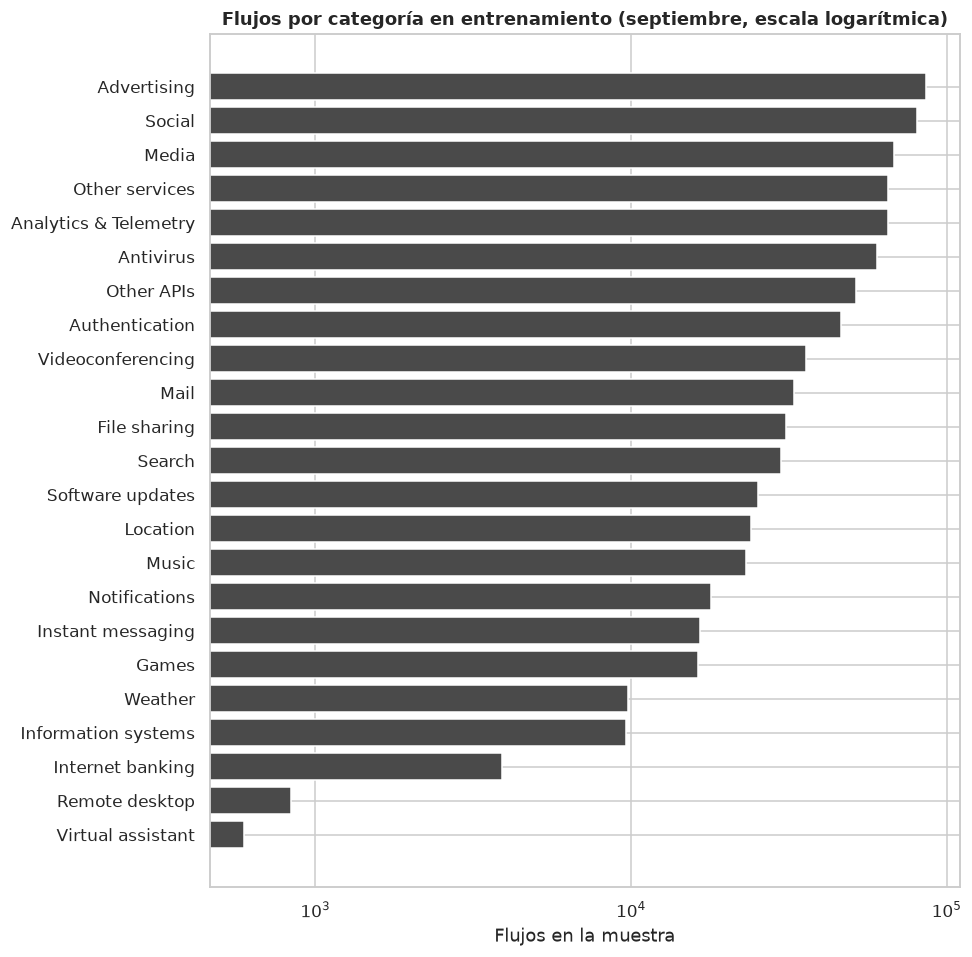

{
 "categorias_en_muestra": 23,
 "categorias_en_entrenamiento": 23,
 "clase_mayor": [
  "Advertising",
  85927,
  10.74
 ],
 "clase_menor": [
  "Virtual assistant",
  593,
  0.0741
 ],
 "razon_desbalance": 144.9,
 "clases_con_menos_de_1000_en_entrenamiento": [
  "Remote desktop",
  "Virtual assistant"
 ],
 "categorias_ausentes_en_prueba": []
}


In [7]:
tab = pd.crosstab(df["CATEGORY"], df["SPLIT"]).reindex(columns=["entrenamiento", "prueba", "deriva"], fill_value=0)
tab = tab.loc[tab["entrenamiento"].sort_values(ascending=False).index]
tab_pct = tab / tab.sum() * 100
pd.concat([tab, tab_pct.add_suffix("_%").round(3)], axis=1).to_csv(OUT / "clases_por_particion.csv")

fig, ax = plt.subplots(figsize=(9, 0.32 * len(tab) + 1.5))
ax.barh(tab.index.astype(str)[::-1], tab["entrenamiento"][::-1], color=GRIS)
ax.set_xscale("log")
ax.set_title("Flujos por categoría en entrenamiento (septiembre, escala logarítmica)")
ax.set_xlabel("Flujos en la muestra")
guardar("04_clases_entrenamiento")

tr = tab["entrenamiento"]
tr_pos = tr[tr > 0]
pesos = (tr_pos.sum() / (len(tr_pos) * tr_pos)).round(4)
(OUT / "pesos_por_clase.json").write_text(json.dumps(pesos.to_dict(), indent=1, ensure_ascii=False))
SUMMARY["clases"] = {
    "categorias_en_muestra": int((tab.sum(axis=1) > 0).sum()),
    "categorias_en_entrenamiento": int(len(tr_pos)),
    "clase_mayor": [str(tr.index[0]), int(tr.iloc[0]), round(float(tab_pct["entrenamiento"].iloc[0]), 2)],
    "clase_menor": [str(tr_pos.index[-1]), int(tr_pos.iloc[-1]), round(float(tab_pct["entrenamiento"].loc[tr_pos.index[-1]]), 4)],
    "razon_desbalance": round(float(tr_pos.iloc[0] / tr_pos.iloc[-1]), 1),
    "clases_con_menos_de_1000_en_entrenamiento": [str(c) for c in tr_pos[tr_pos < 1000].index],
    "categorias_ausentes_en_prueba": [str(c) for c in tab.index[(tab["entrenamiento"] > 0) & (tab["prueba"] == 0)]],
}
print(json.dumps(SUMMARY["clases"], indent=1, ensure_ascii=False))

In [8]:
# Coherencia entre la muestra y la población: participación por categoría en septiembre
pob = cat_mes_pct[TRAIN] * 100 if TRAIN in cat_mes_pct else None
if pob is not None:
    comp = pd.concat([pob.rename("poblacion_%"), tab_pct["entrenamiento"].rename("muestra_%")], axis=1).fillna(0)
    comp.to_csv(OUT / "muestra_vs_poblacion_septiembre.csv")
    dif = (comp["muestra_%"] - comp["poblacion_%"]).abs()
    SUMMARY["muestra_vs_poblacion"] = {"diferencia_absoluta_max_pp": round(float(dif.max()), 3), "correlacion": round(float(comp.corr().iloc[0, 1]), 4)}
    print(SUMMARY["muestra_vs_poblacion"])

{'diferencia_absoluta_max_pp': 0.075, 'correlacion': 1.0}


## 5. Variables estadísticas del flujo

Estas variables alimentan a los modelos clásicos (rama A). Se revisan sus rangos, su asimetría y cómo cambian entre categorías.

                    count        mean           std      min       1%  \
DURATION        3133138.0      26.475  6.108700e+01    0.001    0.020   
BYTES           3133138.0   26589.473  3.149095e+06  222.000  521.000   
BYTES_REV       3133138.0  244151.339  1.366272e+07   76.000  575.000   
PACKETS         3133138.0      89.805  3.074048e+03    1.000    6.000   
PACKETS_REV     3133138.0     206.817  9.576800e+03    1.000    5.000   
PPI_LEN         3133138.0      14.513  8.858000e+00    3.000    3.000   
PPI_DURATION    3133138.0      10.695  3.201300e+01    0.000    0.006   
PPI_ROUNDTRIPS  3133138.0       3.316  1.614000e+00    1.000    1.000   

                     25%       50%       75%          99%           max  \
DURATION           0.196     1.226    18.047      313.331  3.633060e+02   
BYTES           1364.000  2285.000  4200.000   151085.260  2.576897e+09   
BYTES_REV       4360.000  5990.000  8810.000  3429666.960  1.857441e+10   
PACKETS           10.000    13.000    19.0

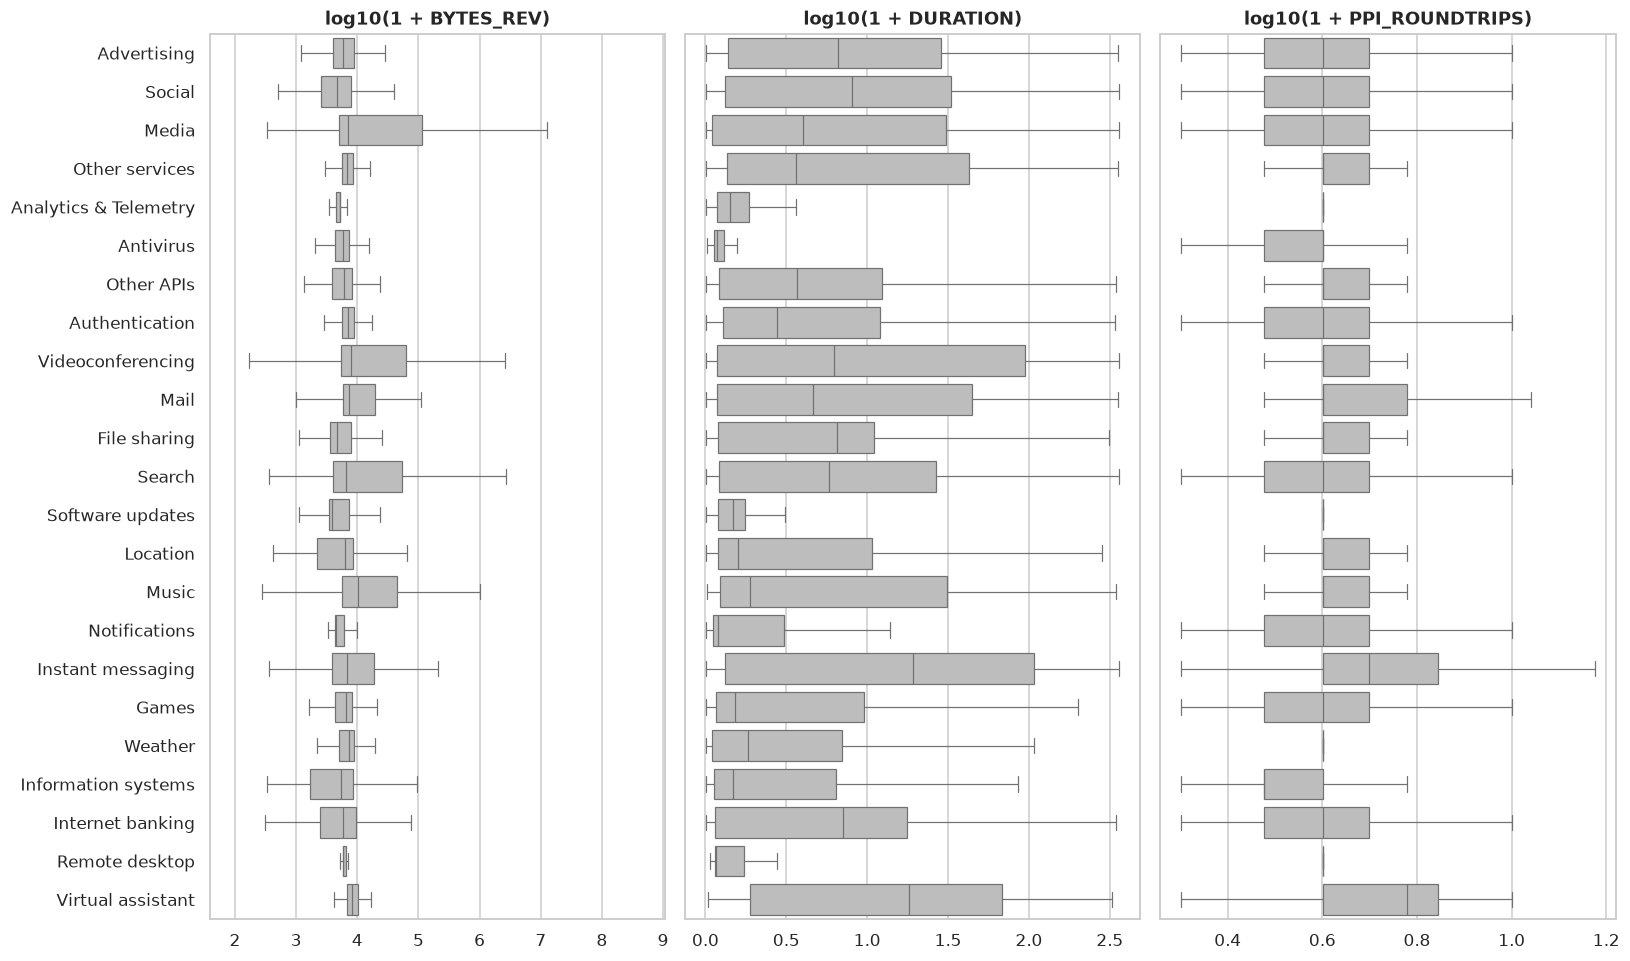

In [9]:
desc = df[SCALARS].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
desc["asimetria"] = df[SCALARS].skew()
desc.to_csv(OUT / "descriptivos_variables_flujo.csv")
print(desc.round(3))
SUMMARY["variables_flujo"] = {
    "asimetria": desc["asimetria"].round(2).to_dict(),
    "variables_muy_asimetricas": [c for c in SCALARS if abs(desc.loc[c, "asimetria"]) > 2],
}

tr_df = df[df["SPLIT"] == "entrenamiento"]
plot_df = tr_df.sample(min(len(tr_df), 200_000), random_state=SEED)
orden_cat = tab.index[tab["entrenamiento"] > 0].astype(str)
fig, axes = plt.subplots(1, 3, figsize=(15, 0.3 * len(orden_cat) + 2), sharey=True)
for ax, col in zip(axes, ["BYTES_REV", "DURATION", "PPI_ROUNDTRIPS"]):
    sns.boxplot(x=np.log10(1 + plot_df[col].astype(float)), y=plot_df["CATEGORY"].astype(str), order=orden_cat,
                color="#bdbdbd", fliersize=0, linewidth=0.8, ax=ax)
    ax.set_title(f"log10(1 + {col})"); ax.set_xlabel(""); ax.set_ylabel("")
guardar("05_variables_por_categoria")

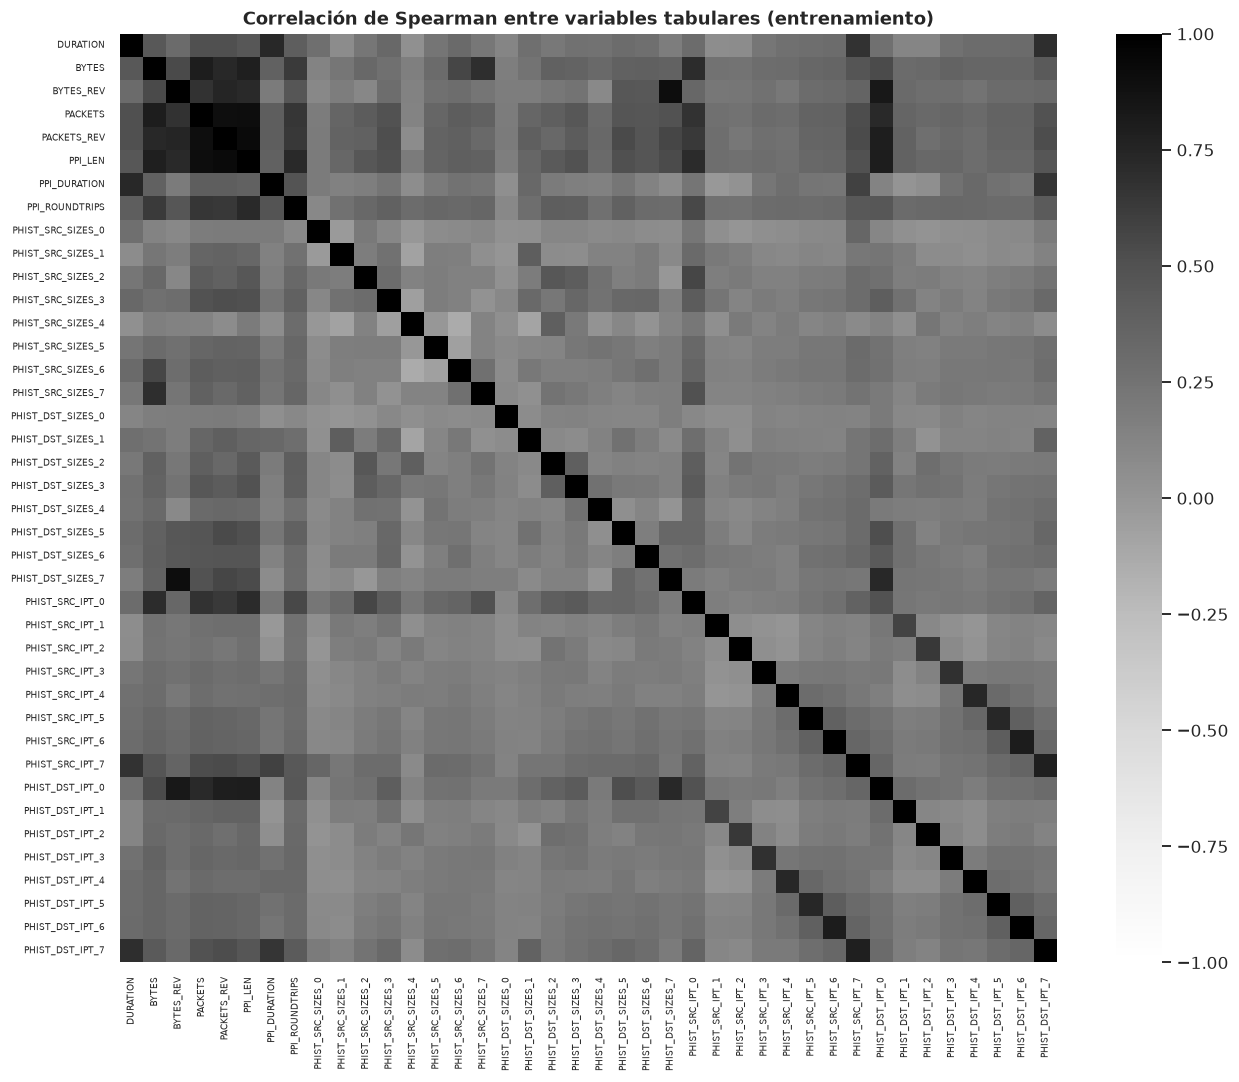

Pares con |rho| > 0,9: 4


In [10]:
num = SCALARS + [c for c in df.columns if c.startswith("PHIST_")]
corr = plot_df[num].corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="Greys", vmin=-1, vmax=1, ax=ax, xticklabels=True, yticklabels=True)
ax.tick_params(labelsize=6)
ax.set_title("Correlación de Spearman entre variables tabulares (entrenamiento)")
guardar("06_correlaciones")
alt = [(a, b, round(float(corr.loc[a, b]), 3)) for i, a in enumerate(num) for b in num[i + 1:] if abs(corr.loc[a, b]) > 0.9]
pd.DataFrame(alt, columns=["variable_1", "variable_2", "spearman"]).to_csv(OUT / "pares_muy_correlacionados.csv", index=False)
SUMMARY["pares_correlacion_mayor_0_9"] = len(alt)
print(f"Pares con |rho| > 0,9: {len(alt)}")

## 6. Secuencia de los primeros 30 paquetes

Es la entrada de la red convolucional y del Transformer (rama B): una matriz de 30 × 3 con tamaño, dirección y tiempo entre paquetes.

{'ppi_len_mediana': 11.0, 'ppi_len_media': 14.51, 'flujos_con_30_paquetes_%': 20.18, 'flujos_con_menos_de_5_paquetes_%': 5.05, 'posiciones_de_relleno_%': 51.62}


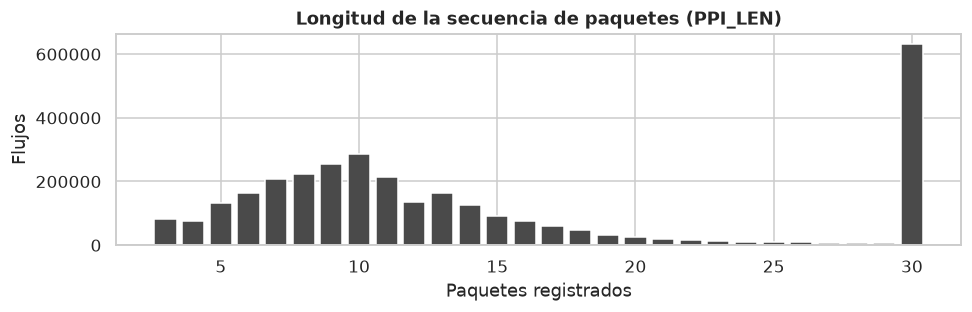

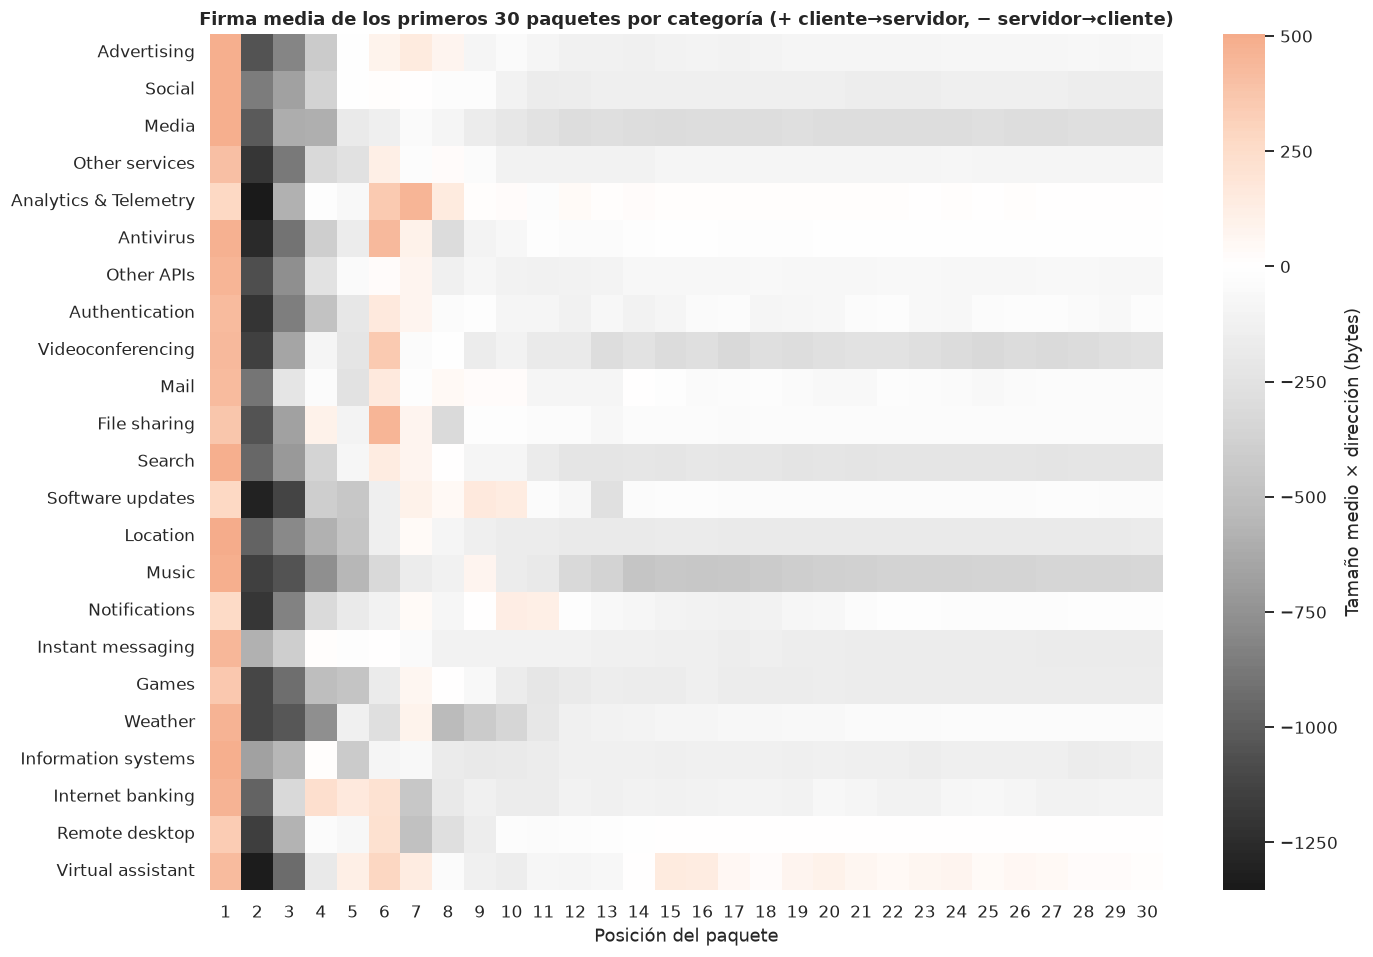

In [11]:
lens = df["PPI_LEN"]
SUMMARY["secuencia"] = {
    "ppi_len_mediana": float(lens.median()),
    "ppi_len_media": round(float(lens.mean()), 2),
    "flujos_con_30_paquetes_%": round(100 * float((lens == SEQ).mean()), 2),
    "flujos_con_menos_de_5_paquetes_%": round(100 * float((lens < 5).mean()), 2),
    "posiciones_de_relleno_%": round(100 * float((dir_arr == 0).mean()), 2),
}
print(SUMMARY["secuencia"])

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(*np.unique(lens, return_counts=True), color=GRIS)
ax.set_title("Longitud de la secuencia de paquetes (PPI_LEN)"); ax.set_xlabel("Paquetes registrados"); ax.set_ylabel("Flujos")
guardar("07_longitud_secuencia")

firmas = (tr_df[SIZE].to_numpy(dtype=np.float32) * tr_df[DIR].to_numpy(dtype=np.float32))
firma_cat = pd.DataFrame(firmas, columns=range(1, SEQ + 1)).groupby(tr_df["CATEGORY"].astype(str).to_numpy()).mean().loc[orden_cat]
firma_cat.to_csv(OUT / "firma_media_por_categoria.csv")
fig, ax = plt.subplots(figsize=(13, 0.32 * len(orden_cat) + 1.5))
sns.heatmap(firma_cat, cmap="RdGy_r", center=0, ax=ax, cbar_kws={"label": "Tamaño medio × dirección (bytes)"})
ax.set_title("Firma media de los primeros 30 paquetes por categoría (+ cliente→servidor, − servidor→cliente)")
ax.set_xlabel("Posición del paquete"); ax.set_ylabel("")
guardar("08_firma_secuencia_por_categoria")

## 7. Fuga de información

`DST_ASN` y `DST_PORT` no describen el comportamiento del flujo sino a quién se conecta. Si predicen la categoría casi por sí solos, el modelo aprendería un atajo que no generaliza. El SNI no se analiza porque es, por construcción, la fuente de la etiqueta.

In [12]:
def pureza(col):
    g = tr_df.groupby(col, observed=True)["CATEGORY"].agg(lambda s: s.value_counts().iloc[0] / len(s))
    w = tr_df[col].value_counts()
    return float((g * w.reindex(g.index)).sum() / w.sum())

fuga = {}
y = tr_df["CATEGORY"].astype(str)
for col in ["DST_ASN", "DST_PORT"]:
    fuga[col] = {"valores_distintos": int(tr_df[col].nunique()),
                 "NMI_con_categoria": round(float(normalized_mutual_info_score(y, tr_df[col])), 4),
                 "pureza_ponderada": round(pureza(col), 4)}
for col in ["PPI_LEN", "PPI_ROUNDTRIPS"]:
    fuga[col + " (referencia)"] = {"NMI_con_categoria": round(float(normalized_mutual_info_score(y, tr_df[col])), 4)}
SUMMARY["fuga"] = fuga
pd.DataFrame(fuga).T.to_csv(OUT / "fuga_de_informacion.csv")
print(json.dumps(fuga, indent=1, ensure_ascii=False))

{
 "DST_ASN": {
  "valores_distintos": 139,
  "NMI_con_categoria": 0.4302,
  "pureza_ponderada": 0.4131
 },
 "DST_PORT": {
  "valores_distintos": 1,
  "NMI_con_categoria": 0.0,
  "pureza_ponderada": 0.1074
 },
 "PPI_LEN (referencia)": {
  "NMI_con_categoria": 0.08
 },
 "PPI_ROUNDTRIPS (referencia)": {
  "NMI_con_categoria": 0.0469
 }
}


## 8. Secuencias repetidas entre entrenamiento y prueba

Se usa una huella de la secuencia (tamaño × dirección de los 30 paquetes). Si muchos flujos de prueba tienen una secuencia idéntica a alguna de entrenamiento, el desempeño medido estaría inflado.

In [13]:
h_tr = set(df.loc[df["SPLIT"] == "entrenamiento", "SEQ_HASH"].to_numpy())
te = df[df["SPLIT"] == "prueba"]
en_tr = te["SEQ_HASH"].isin(h_tr)
por_len = en_tr.groupby(pd.cut(te["PPI_LEN"], [0, 2, 5, 10, 20, 30])).mean().mul(100).round(2)
por_len.index = por_len.index.astype(str)
SUMMARY["repetidos"] = {
    "prueba_con_secuencia_vista_en_entrenamiento_%": round(100 * float(en_tr.mean()), 2),
    "por_longitud_%": por_len.to_dict(),
    "repetidos_dentro_de_entrenamiento_%": round(100 * float(df.loc[df["SPLIT"] == "entrenamiento", "SEQ_HASH"].duplicated().mean()), 2),
}
por_cat = en_tr.groupby(te["CATEGORY"].astype(str)).mean().mul(100).round(2).sort_values(ascending=False)
por_cat.to_csv(OUT / "repetidos_por_categoria.csv")
print(json.dumps(SUMMARY["repetidos"], indent=1, ensure_ascii=False))

{
 "prueba_con_secuencia_vista_en_entrenamiento_%": 30.33,
 "por_longitud_%": {
  "(0, 2]": NaN,
  "(2, 5]": 81.76,
  "(5, 10]": 48.52,
  "(10, 20]": 15.76,
  "(20, 30]": 2.31
 },
 "repetidos_dentro_de_entrenamiento_%": 31.87
}


## 9. Deriva dentro de la muestra

Se compara septiembre con cada mes siguiente: la mezcla de categorías (Jensen-Shannon) y la distribución de las variables principales (estadístico de Kolmogorov-Smirnov).

In [14]:
mix = pd.crosstab(df["CATEGORY"], df["MONTH"], normalize="columns")
deriva = {}
base = df[df["MONTH"] == TRAIN]
for mes in [TEST] + DRIFT:
    if mes not in mix.columns:
        continue
    cur = df[df["MONTH"] == mes]
    ks = {c: round(float(ks_2samp(base[c].sample(min(len(base), 100_000), random_state=SEED),
                                   cur[c].sample(min(len(cur), 100_000), random_state=SEED)).statistic), 4)
          for c in ["BYTES", "BYTES_REV", "DURATION", "PPI_LEN", "SIZE_0", "SIZE_1"]}
    deriva[mes] = {"JS_categorias": round(float(jensenshannon(mix[TRAIN], mix[mes], base=2)), 4), "KS_variables": ks}
SUMMARY["deriva_muestra"] = deriva
print(json.dumps(deriva, indent=1, ensure_ascii=False))

{
 "2022-10": {
  "JS_categorias": 0.0499,
  "KS_variables": {
   "BYTES": 0.0121,
   "BYTES_REV": 0.0169,
   "DURATION": 0.0244,
   "PPI_LEN": 0.0125,
   "SIZE_0": 0.0306,
   "SIZE_1": 0.0324
  }
 },
 "2022-11": {
  "JS_categorias": 0.0616,
  "KS_variables": {
   "BYTES": 0.0098,
   "BYTES_REV": 0.0147,
   "DURATION": 0.0413,
   "PPI_LEN": 0.0146,
   "SIZE_0": 0.0276,
   "SIZE_1": 0.0369
  }
 },
 "2022-12": {
  "JS_categorias": 0.0605,
  "KS_variables": {
   "BYTES": 0.0155,
   "BYTES_REV": 0.0244,
   "DURATION": 0.0266,
   "PPI_LEN": 0.0102,
   "SIZE_0": 0.038,
   "SIZE_1": 0.0338
  }
 }
}


## 10. Especificación de entrada para los modelos

Este bloque deja fijado qué recibe cada rama del pipeline. Es la conexión directa con la Ficha de Decisión Técnica.

In [15]:
flags = [c for c in df.columns if c.startswith("FLAG_") or c.startswith("FLOW_ENDREASON_")]
phist = [c for c in df.columns if c.startswith("PHIST_")]
protocolos = df["PROTOCOL"].nunique()
spec = {
    "etiqueta": "CATEGORY",
    "particiones": {"entrenamiento": TRAIN + " (20 % para validacion)", "prueba": TEST, "deriva": DRIFT},
    "rama_A_tabular": {"modelos": ["Random Forest", "XGBoost"], "variables": SCALARS + flags + phist,
                        "transformacion": "log10(1 + x) en variables asimetricas y escalado estandar"},
    "rama_B_secuencia": {"modelos": ["CNN 1D", "Transformer encoder"], "forma": [SEQ, 3],
                          "canales": ["SIZE_i", "DIR_i", "IPT_i"], "relleno": "ceros en posiciones sin paquete"},
    "excluidas": {"TLS_SNI": "fuente de la etiqueta", "TLS_JA3": "identifica al cliente",
                  "SRC_IP, DST_IP": "identifican usuarios y servidores",
                  "DST_ASN, DST_PORT": "fuga de informacion (seccion 7)",
                  "PROTOCOL": "constante" if protocolos == 1 else "revisar",
                  "APP": "etiqueta fina; no es entrada", "TIME_FIRST": "solo para particionar"},
    "pesos_por_clase": "pesos_por_clase.json",
}
(OUT / "especificacion_entrada.json").write_text(json.dumps(spec, indent=1, ensure_ascii=False))
print(json.dumps(spec, indent=1, ensure_ascii=False))

{
 "etiqueta": "CATEGORY",
 "particiones": {
  "entrenamiento": "2022-09 (20 % para validacion)",
  "prueba": "2022-10",
  "deriva": [
   "2022-11",
   "2022-12"
  ]
 },
 "rama_A_tabular": {
  "modelos": [
   "Random Forest",
   "XGBoost"
  ],
  "variables": [
   "DURATION",
   "BYTES",
   "BYTES_REV",
   "PACKETS",
   "PACKETS_REV",
   "PPI_LEN",
   "PPI_DURATION",
   "PPI_ROUNDTRIPS",
   "FLAG_CWR",
   "FLAG_CWR_REV",
   "FLAG_ECE",
   "FLAG_ECE_REV",
   "FLAG_URG",
   "FLAG_URG_REV",
   "FLAG_ACK",
   "FLAG_ACK_REV",
   "FLAG_PSH",
   "FLAG_PSH_REV",
   "FLAG_RST",
   "FLAG_RST_REV",
   "FLAG_SYN",
   "FLAG_SYN_REV",
   "FLAG_FIN",
   "FLAG_FIN_REV",
   "FLOW_ENDREASON_IDLE",
   "FLOW_ENDREASON_ACTIVE",
   "FLOW_ENDREASON_END",
   "FLOW_ENDREASON_OTHER",
   "PHIST_SRC_SIZES_0",
   "PHIST_SRC_SIZES_1",
   "PHIST_SRC_SIZES_2",
   "PHIST_SRC_SIZES_3",
   "PHIST_SRC_SIZES_4",
   "PHIST_SRC_SIZES_5",
   "PHIST_SRC_SIZES_6",
   "PHIST_SRC_SIZES_7",
   "PHIST_DST_SIZES_0",
   "PHIST_DST_SI

## 11. Resumen y archivo de resultados

Se guarda el resumen completo y se empaqueta la carpeta de resultados para compartirla.

In [16]:
(OUT / "resumen_eda.json").write_text(json.dumps(SUMMARY, indent=1, ensure_ascii=False, default=str))
zip_path = shutil.make_archive(str(OUT.parent / "eda_resultados"), "zip", OUT)
print("Resumen:", OUT / "resumen_eda.json")
print("Figuras:", sorted(p.name for p in FIG.glob("*.png")))
print("Archivo para compartir:", zip_path)

Resumen: /home/ransomware/proyecto_integrador/jairojhayya/results/eda/resumen_eda.json
Figuras: ['01_flujos_por_dia.png', '02_categorias_por_mes_anio.png', '03_deriva_js_anio.png', '04_clases_entrenamiento.png', '05_variables_por_categoria.png', '06_correlaciones.png', '07_longitud_secuencia.png', '08_firma_secuencia_por_categoria.png']
Archivo para compartir: /home/ransomware/proyecto_integrador/jairojhayya/results/eda_resultados.zip
